# Sigmoide et neurone binaire

Ce notebook repond a la question : pourquoi une sigmoide pour un neurone binaire, et que fait-elle en 2D, 3D et 4D.

Idee centrale :

- on calcule d'abord un score affine `z = w^T x + b`
- on veut ensuite une quantite interpretable comme probabilite
- on applique donc une fonction `sigma : R -> (0,1)`
- on seuillera plus tard cette probabilite pour obtenir `0` ou `1`

Pourquoi la sigmoide s'est imposee :

- elle transforme tout score reel en valeur dans `(0,1)`
- elle est monotone : un score plus grand donne une probabilite plus grande
- elle est lisse et derivable partout, donc utilisable pour l'apprentissage par gradient
- elle est naturellement liee au modele de Bernoulli et a la regression logistique
- son inverse, le logit, transforme une probabilite en score lineaire : `log(p / (1-p)) = w^T x + b`

Pourquoi pas simplement MCO :

- un modele lineaire pur peut sortir des valeurs hors de `[0,1]`
- pour une cible binaire, le bon modele statistique est Bernoulli, pas gaussien
- le cout naturel devient la log-vraisemblance negative, c'est-a-dire la cross-entropy
- avec `sigmoide + cross-entropy`, l'optimisation d'un neurone logistique reste convexe en `w, b`


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("default")
np.set_printoptions(precision=4, suppress=True)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logit(p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return np.log(p / (1 - p))


Matplotlib is building the font cache; this may take a moment.


## 1. Forme de la sigmoide

La somme `w^T x + b` n'est pas sigmoide. C'est un score affine. La sigmoide agit **apres** ce score.

On a donc :

- score : `z = w^T x + b`
- probabilite : `p = sigma(z)`
- decision : `1 si p >= seuil, sinon 0`


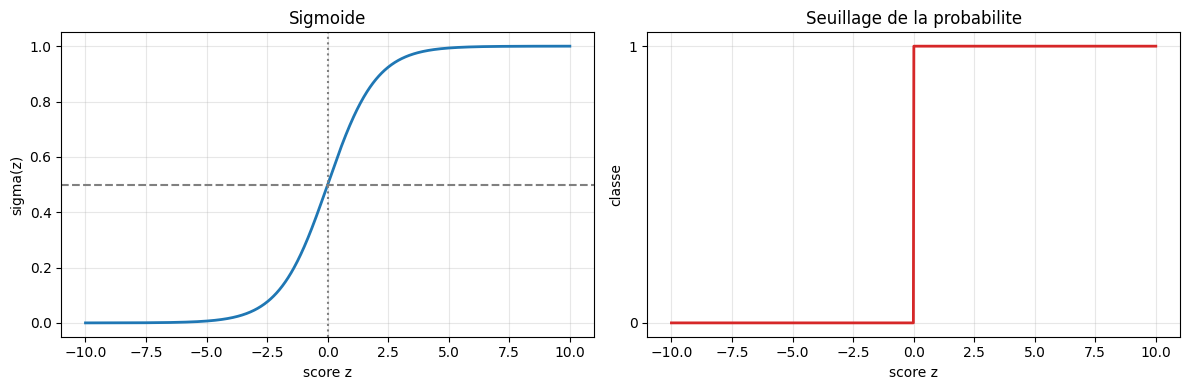

In [2]:
z = np.linspace(-10, 10, 1000)
p = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, p, color="tab:blue", linewidth=2)
axes[0].axhline(0.5, color="gray", linestyle="--")
axes[0].axvline(0, color="gray", linestyle=":")
axes[0].set_title("Sigmoide")
axes[0].set_xlabel("score z")
axes[0].set_ylabel("sigma(z)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(z, (p >= 0.5).astype(float), color="tab:red", linewidth=2)
axes[1].set_title("Seuillage de la probabilite")
axes[1].set_xlabel("score z")
axes[1].set_ylabel("classe")
axes[1].set_yticks([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Visualisation en 2 dimensions

Ici `x = (x1, x2)`. Le neurone definit une frontiere `w1 x1 + w2 x2 + b = 0`.

- d'un cote, `p > 0.5`
- de l'autre, `p < 0.5`
- la courbe de niveau `p = 0.5` est exactement la droite de decision


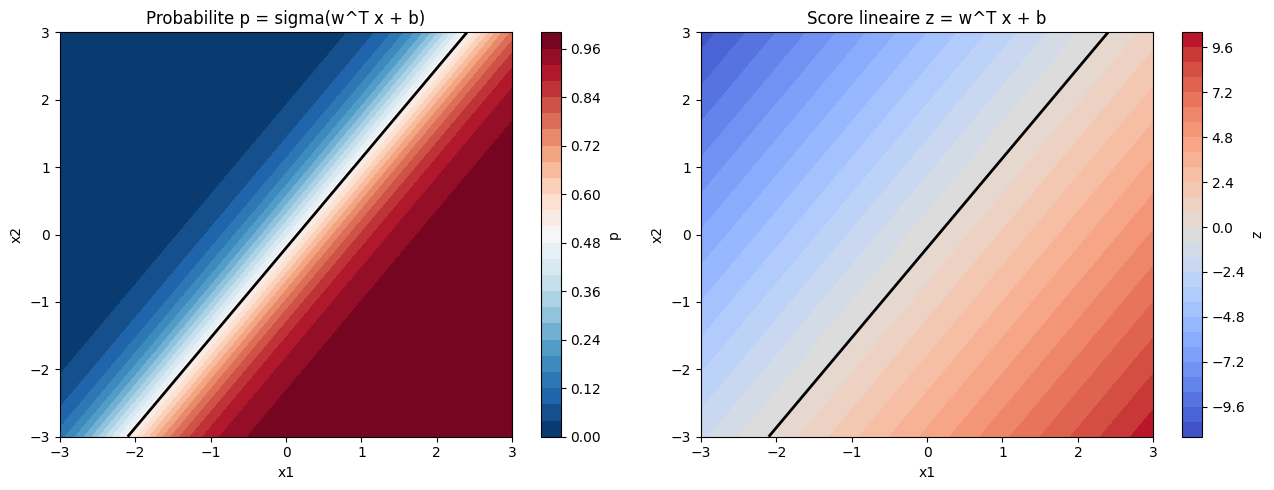

In [3]:
w2 = np.array([2.0, -1.5])
b2 = -0.3

x1 = np.linspace(-3, 3, 250)
x2 = np.linspace(-3, 3, 250)
X1, X2 = np.meshgrid(x1, x2)
Z2 = w2[0] * X1 + w2[1] * X2 + b2
P2 = sigmoid(Z2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].contourf(X1, X2, P2, levels=30, cmap="RdBu_r")
axes[0].contour(X1, X2, P2, levels=[0.5], colors="black", linewidths=2)
axes[0].set_title("Probabilite p = sigma(w^T x + b)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
fig.colorbar(im, ax=axes[0], label="p")

im2 = axes[1].contourf(X1, X2, Z2, levels=30, cmap="coolwarm")
axes[1].contour(X1, X2, Z2, levels=[0.0], colors="black", linewidths=2)
axes[1].set_title("Score lineaire z = w^T x + b")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
fig.colorbar(im2, ax=axes[1], label="z")

plt.tight_layout()
plt.show()


## 3. Visualisation en 3 dimensions

Ici `x = (x1, x2, x3)`. La frontiere `w^T x + b = 0` devient un plan dans l'espace.

On montre :

- le plan de decision `z = 0`
- des points colores par leur probabilite `sigma(w^T x + b)`


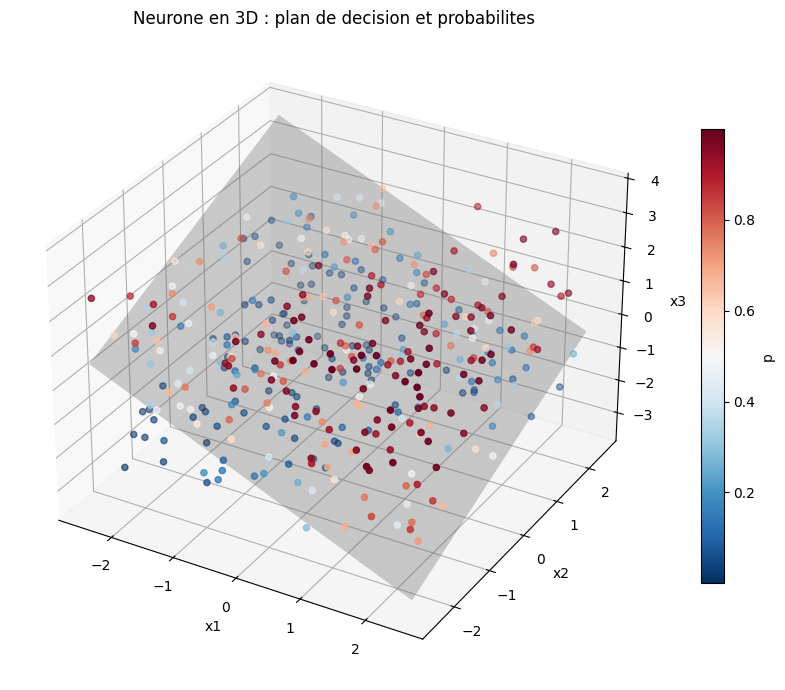

In [4]:
w3 = np.array([1.2, -0.9, 1.5])
b3 = -0.2

rng = np.random.default_rng(42)
pts = rng.uniform(-2.5, 2.5, size=(400, 3))
z3_pts = pts @ w3 + b3
p3_pts = sigmoid(z3_pts)

gx = np.linspace(-2.5, 2.5, 20)
gy = np.linspace(-2.5, 2.5, 20)
GX, GY = np.meshgrid(gx, gy)
GZ = -(w3[0] * GX + w3[1] * GY + b3) / w3[2]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(GX, GY, GZ, alpha=0.3, color="gray", edgecolor="none")
sc = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=p3_pts, cmap="RdBu_r", s=20)
ax.set_title("Neurone en 3D : plan de decision et probabilites")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
fig.colorbar(sc, ax=ax, shrink=0.7, label="p")
plt.tight_layout()
plt.show()


## 4. Visualisation en 4 dimensions

En 4D, on ne peut pas tout dessiner d'un seul coup dans l'espace ordinaire. On travaille donc par **coupes**.

On fixe `x3` et `x4`, puis on regarde comment la probabilite varie selon `x1` et `x2`.

Cela montre que :

- le neurone reste un score affine en 4D
- la sigmoide continue de comprimer ce score dans `(0,1)`
- changer `x3` et `x4` deplace la frontiere visible dans la coupe `(x1, x2)`


/tmp/ipykernel_366059/3694440456.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


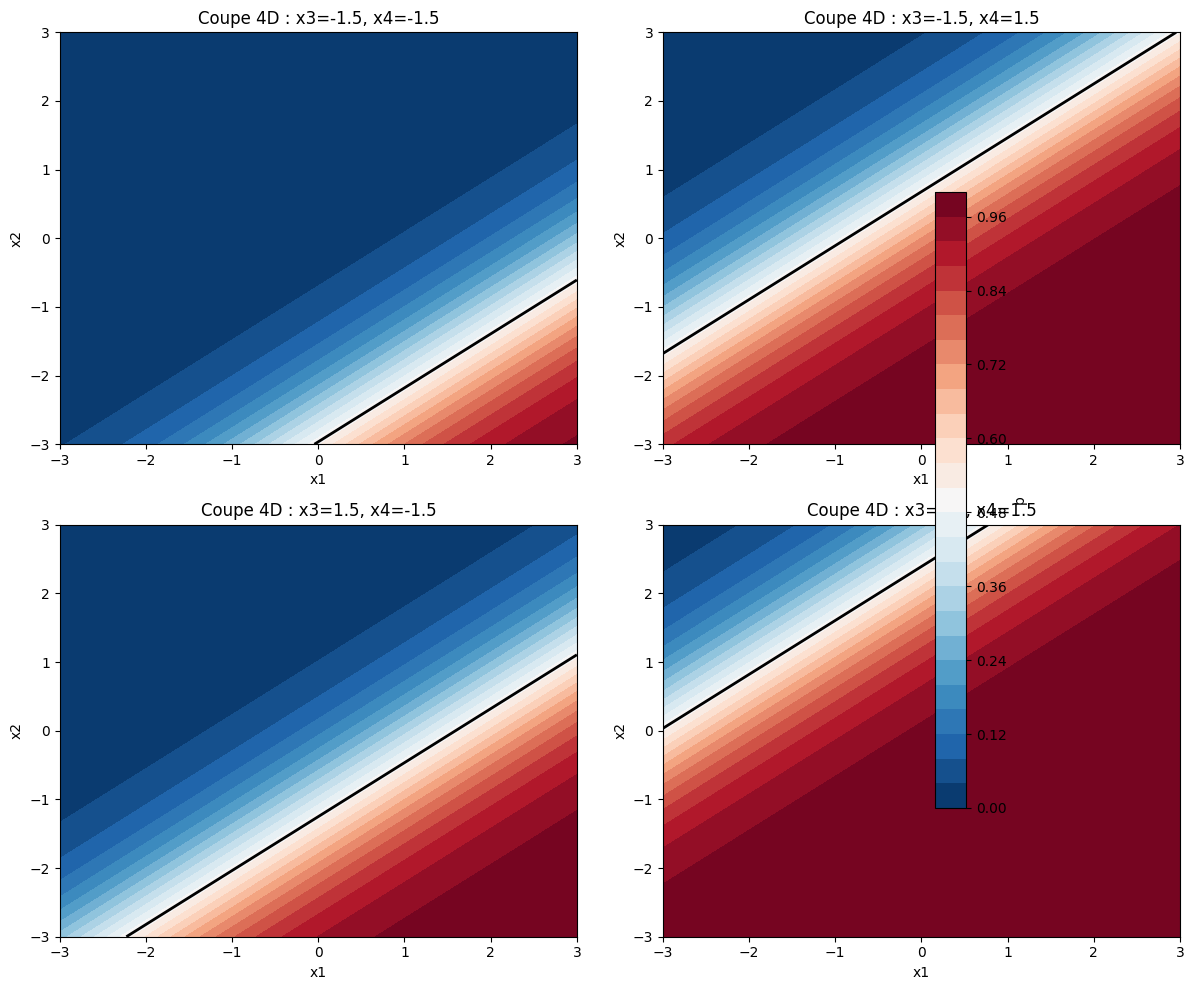

In [ ]:
w4 = np.array([1.1, -1.4, 0.8, 1.7])
b4 = -0.4

x1 = np.linspace(-3, 3, 220)
x2 = np.linspace(-3, 3, 220)
X1, X2 = np.meshgrid(x1, x2)

slices = [
    (-1.5, -1.5),
    (-1.5,  1.5),
    ( 1.5, -1.5),
    ( 1.5,  1.5),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (x3_fixed, x4_fixed) in zip(axes.ravel(), slices):
    Z4 = w4[0] * X1 + w4[1] * X2 + w4[2] * x3_fixed + w4[3] * x4_fixed + b4
    P4 = sigmoid(Z4)
    im = ax.contourf(X1, X2, P4, levels=30, cmap="RdBu_r")
    ax.contour(X1, X2, P4, levels=[0.5], colors="black", linewidths=2)
    ax.set_title(f"Coupe 4D : x3={x3_fixed}, x4={x4_fixed}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="p")
plt.tight_layout()
plt.show()

## 5. Message essentiel

Ce n'est pas la sigmoide qui cree la separation geometrique : la separation vient du score affine `w^T x + b`.

La sigmoide sert a :

- convertir ce score en probabilite
- garder une fonction lisse et derivable
- rendre le modele coherent avec une variable cible binaire

Donc la bonne chaine logique est :

`image -> vecteur x -> score z -> probabilite p -> perte -> apprentissage de w et b`
